In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

# SETUP

In [16]:
!pip install pydicom --quiet

# Instalar librerías

In [29]:
import numpy as np
import pandas as pd
import pydicom
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from glob import glob

# Imports y rutas

In [22]:
import os

RUTA_DATOS   = "/kaggle/input/competitions/rsna-pneumonia-detection-challenge"
RUTA_OUTPUTS = '/kaggle/working'
TRAIN_IMG_DIR = os.path.join(RUTA_DATOS, "stage_2_train_images")
TEST_IMG_DIR = os.path.join(RUTA_DATOS, "stage_2_test_images")
 
print(os.listdir(RUTA_DATOS))

['stage_2_train_images', 'stage_2_sample_submission.csv', 'stage_2_detailed_class_info.csv', 'GCP Credits Request Link - RSNA.txt', 'stage_2_train_labels.csv', 'stage_2_test_images']


# EDA

In [24]:
# %% [CELDA 2] -- Cargar CSVs
train_labels = pd.read_csv(os.path.join(RUTA_DATOS, "stage_2_train_labels.csv"))
detailed_class = pd.read_csv(os.path.join(RUTA_DATOS, "stage_2_detailed_class_info.csv"))
sample_sub = pd.read_csv(os.path.join(RUTA_DATOS, "stage_2_sample_submission.csv"))
 
print("train_labels:", train_labels.shape)
print("detailed_class:", detailed_class.shape)
print("sample_sub:", sample_sub.shape)
 
train_labels.head(10)

train_labels: (30227, 6)
detailed_class: (30227, 2)
sample_sub: (3000, 2)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


In [25]:
# %% [CELDA 3] -- Vista rápida de detailed_class_info
detailed_class.head(10)

,patientId,class
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,No Lung Opacity / Not Normal
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,No Lung Opacity / Not Normal
2,00322d4d-1c29-4943-afc9-b6754be640eb,No Lung Opacity / Not Normal
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,Normal
4,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity
5,00436515-870c-4b36-a041-de91049b9ab4,Lung Opacity
6,00569f44-917d-4c86-a842-81832af98c30,No Lung Opacity / Not Normal
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,No Lung Opacity / Not Normal
8,00704310-78a8-4b38-8475-49f4573b2dbb,Lung Opacity
9,00704310-78a8-4b38-8475-49f4573b2dbb,Lung Opacity


In [26]:
# %% [CELDA 4] -- Pacientes únicos vs filas totales
n_rows = len(train_labels)
n_patients = train_labels["patientId"].nunique()
print(f"Filas totales en train_labels: {n_rows}")
print(f"Pacientes (imágenes) únicos: {n_patients}")
print(f"=> Hay pacientes con más de 1 bounding box" if n_rows > n_patients else "1 fila por paciente")

Filas totales en train_labels: 30227
Pacientes (imágenes) únicos: 26684
=> Hay pacientes con más de 1 bounding box


In [27]:
# Cuántas cajas tiene cada paciente positivo
boxes_per_patient = train_labels[train_labels["Target"] == 1].groupby("patientId").size()
print("\nDistribución de número de cajas por paciente positivo:")
print(boxes_per_patient.value_counts().sort_index())


Distribución de número de cajas por paciente positivo:
1    2614
2    3266
3     119
4      13
Name: count, dtype: int64


Target
0    20672
1     6012
Name: count, dtype: int64
Target
0    77.469645
1    22.530355
Name: count, dtype: float64


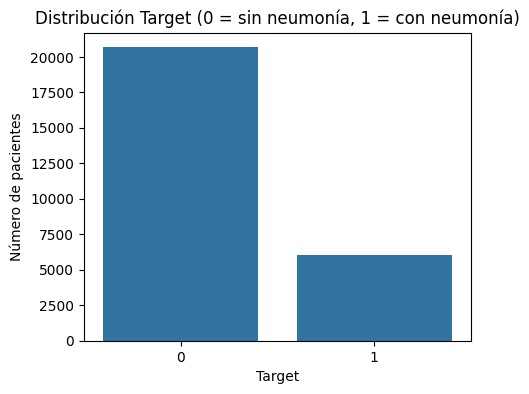

In [30]:
# %% [CELDA 5] -- Distribución de clases (Target binario)
target_counts = train_labels.drop_duplicates("patientId")["Target"].value_counts()
print(target_counts)
print(target_counts / target_counts.sum() * 100)
 
plt.figure(figsize=(5, 4))
sns.countplot(x=train_labels.drop_duplicates("patientId")["Target"])
plt.title("Distribución Target (0 = sin neumonía, 1 = con neumonía)")
plt.xlabel("Target")
plt.ylabel("Número de pacientes")
plt.show()

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64
class
No Lung Opacity / Not Normal    39.11
Lung Opacity                    31.61
Normal                          29.28
Name: count, dtype: float64


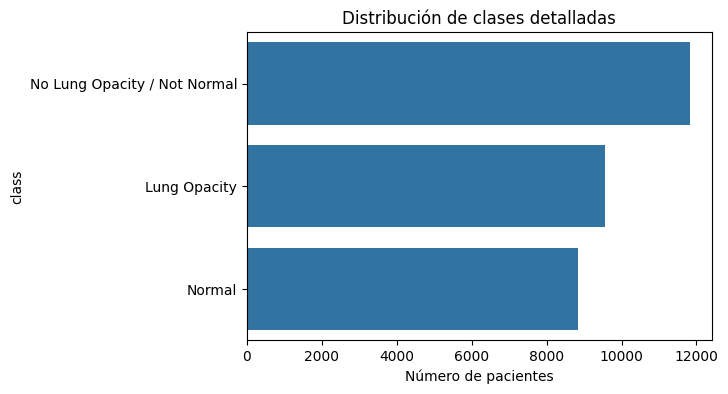

class                         Target
Lung Opacity                  1          9555
No Lung Opacity / Not Normal  0         11821
Normal                        0          8851
Name: count, dtype: int64


In [31]:
# %% [CELDA 6] -- Distribución de las 3 clases detalladas
class_counts = detailed_class["class"].value_counts()
print(class_counts)
print((class_counts / class_counts.sum() * 100).round(2))
 
plt.figure(figsize=(6, 4))
sns.countplot(y=detailed_class["class"], order=class_counts.index)
plt.title("Distribución de clases detalladas")
plt.xlabel("Número de pacientes")
plt.show()
 
# Pregunta clave para resolver con esto:
# ¿"No Lung Opacity / Not Normal" y "Normal" ambos tienen Target=0?
merged_check = detailed_class.merge(
    train_labels.drop_duplicates("patientId")[["patientId", "Target"]],
    on="patientId"
)
print(merged_check.groupby("class")["Target"].value_counts())

In [32]:
# %% [CELDA 7] -- Leer un DICOM de ejemplo y ver metadatos
sample_id = train_labels["patientId"].iloc[0]
sample_path = os.path.join(TRAIN_IMG_DIR, f"{sample_id}.dcm")
dcm = pydicom.dcmread(sample_path)
 
print(dcm)  # metadatos completos (edad, sexo, vista, modalidad, etc.)

Dataset.file_meta -------------------------------
(0002,0000) File Meta Information Group Length  UL: 202
(0002,0001) File Meta Information Version       OB: b'\x00\x01'
(0002,0002) Media Storage SOP Class UID         UI: Secondary Capture Image Storage
(0002,0003) Media Storage SOP Instance UID      UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0002,0010) Transfer Syntax UID                 UI: JPEG Baseline (Process 1)
(0002,0012) Implementation Class UID            UI: 1.2.276.0.7230010.3.0.3.6.0
(0002,0013) Implementation Version Name         SH: 'OFFIS_DCMTK_360'
-------------------------------------------------
(0008,0005) Specific Character Set              CS: 'ISO_IR 100'
(0008,0016) SOP Class UID                       UI: Secondary Capture Image Storage
(0008,0018) SOP Instance UID                    UI: 1.2.276.0.7230010.3.1.4.8323329.28530.1517874485.775526
(0008,0020) Study Date                          DA: '19010101'
(0008,0030) Study Time                  

In [33]:
# %% [CELDA 8] -- Extraer metadatos útiles de TODOS los DICOM (puede tardar varios minutos)
# Si quieres ir más rápido al principio, usa una muestra: train_labels["patientId"].unique()[:2000]
def extract_dicom_meta(patient_id, img_dir=TRAIN_IMG_DIR):
    path = os.path.join(img_dir, f"{patient_id}.dcm")
    dcm = pydicom.dcmread(path, stop_before_pixels=True)  # más rápido: no carga pixeles
    return {
        "patientId": patient_id,
        "PatientAge": dcm.PatientAge,
        "PatientSex": dcm.PatientSex,
        "ViewPosition": dcm.ViewPosition,  # AP o PA
        "Rows": dcm.Rows,
        "Columns": dcm.Columns,
    }
 
unique_patients = train_labels["patientId"].unique()
meta_list = [extract_dicom_meta(pid) for pid in unique_patients]
meta_df = pd.DataFrame(meta_list)
 
# Limpiar edad (a veces viene como string con ceros raros)
meta_df["PatientAge"] = pd.to_numeric(meta_df["PatientAge"], errors="coerce")
meta_df = meta_df[meta_df["PatientAge"] < 120]  # filtrar outliers de edad mal codificados
 
meta_df.head()

,patientId,PatientAge,PatientSex,ViewPosition,Rows,Columns
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,51,F,PA,1024,1024
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,48,F,PA,1024,1024
2,00322d4d-1c29-4943-afc9-b6754be640eb,19,M,AP,1024,1024
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,28,M,PA,1024,1024
4,00436515-870c-4b36-a041-de91049b9ab4,32,F,AP,1024,1024


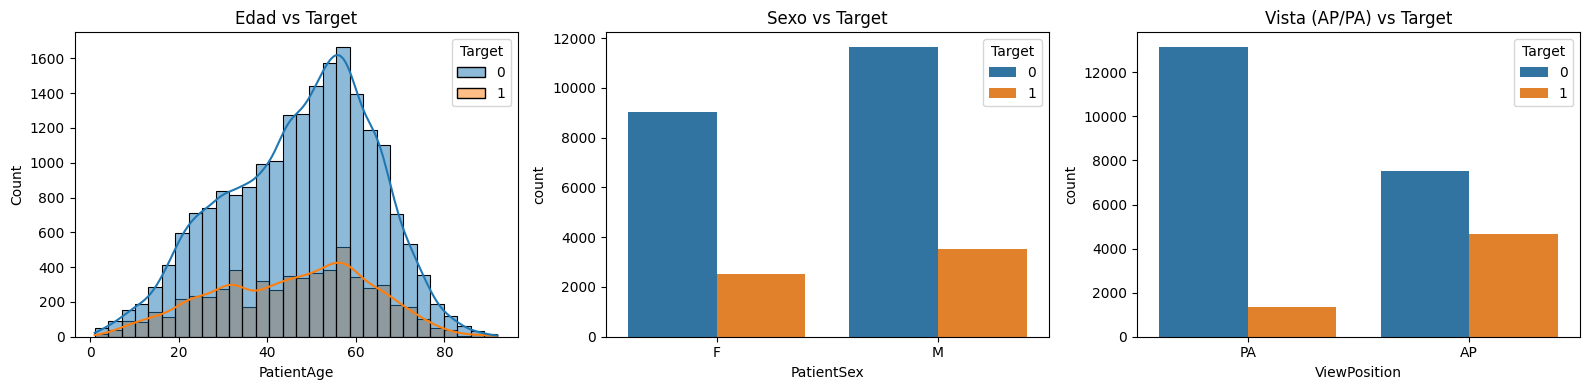

In [44]:
# %% [CELDA 9] -- Cruzar metadatos con Target
full_meta = meta_df.merge(
    train_labels.drop_duplicates("patientId")[["patientId", "Target"]],
    on="patientId"
)
 
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
 
sns.histplot(data=full_meta, x="PatientAge", hue="Target", kde=True, ax=axes[0], bins=30)
axes[0].set_title("Edad vs Target")
 
sns.countplot(data=full_meta, x="PatientSex", hue="Target", ax=axes[1])
axes[1].set_title("Sexo vs Target")
 
sns.countplot(data=full_meta, x="ViewPosition", hue="Target", ax=axes[2])
axes[2].set_title("Vista (AP/PA) vs Target")
 
plt.tight_layout()
plt.show()
 
# Qué observar:
# - ¿La proporción de neumonía cambia mucho entre AP y PA? (Suele ser así:
#   las vistas AP -tomadas a pacientes más graves, en cama- correlacionan
#   más con Target=1 que las PA).
# - ¿Hay sesgo de edad o sexo?

VISTA (AP/PA) vs TARGET

Conteo absoluto:
Target            0     1
ViewPosition             
AP             7509  4664
PA            13158  1348

% de neumonía dentro de cada vista (por fila):
Target            0      1
ViewPosition              
AP            61.69  38.31
PA            90.71   9.29

Tasa de Target=1 por vista:
ViewPosition
AP    38.31
PA     9.29
Name: Target, dtype: float64

SEXO vs TARGET

Conteo absoluto:
Target          0     1
PatientSex             
F            9014  2502
M           11653  3510

% de neumonía dentro de cada sexo:
Target          0      1
PatientSex              
F           78.27  21.73
M           76.85  23.15

Tasa de Target=1 por sexo:
PatientSex
F    21.73
M    23.15
Name: Target, dtype: float64

EDAD vs TARGET

Estadísticas de edad por grupo:
          count   mean    std  min   25%   50%   75%   max
Target                                                    
0       20667.0  47.43  16.51  1.0  35.0  50.0  60.0  92.0
1        6012.0  45.5

/tmp/ipykernel_58/2201928307.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  tasa_por_edad = full_meta.groupby("AgeBin")["Target"].mean() * 100
/tmp/ipykernel_58/2201928307.py:51: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  conteo_por_edad = full_meta.groupby("AgeBin")["Target"].count()


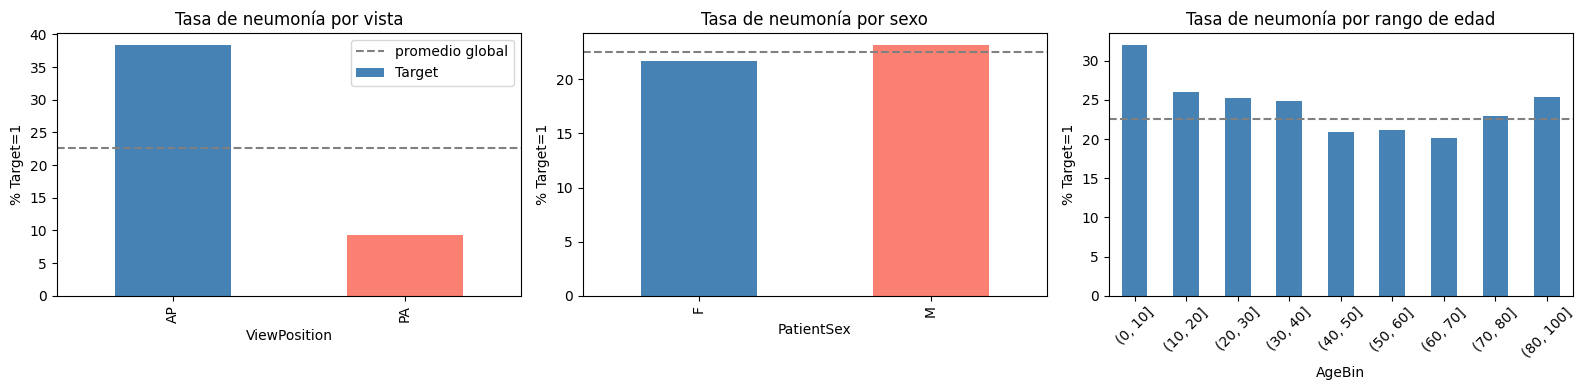


TEST CHI-CUADRADO (¿la relación es estadísticamente significativa?)

ViewPosition: chi2=3191.79, p-value=0.00e+00
  -> Relación estadísticamente significativa (p < 0.05)

PatientSex: chi2=7.50, p-value=6.16e-03
  -> Relación estadísticamente significativa (p < 0.05)


In [45]:
# %% [CELDA 9bis] -- Cuantificar relación de metadatos con Target

# --- 1) Vista (AP/PA) vs Target ---
print("="*60)
print("VISTA (AP/PA) vs TARGET")
print("="*60)

view_target = pd.crosstab(full_meta["ViewPosition"], full_meta["Target"])
view_target_pct = pd.crosstab(full_meta["ViewPosition"], full_meta["Target"], normalize="index") * 100

print("\nConteo absoluto:")
print(view_target)
print("\n% de neumonía dentro de cada vista (por fila):")
print(view_target_pct.round(2))

# Tasa de positivos por vista, en una sola línea fácil de leer
tasa_por_vista = full_meta.groupby("ViewPosition")["Target"].mean() * 100
print("\nTasa de Target=1 por vista:")
print(tasa_por_vista.round(2))


# --- 2) Sexo vs Target ---
print("\n" + "="*60)
print("SEXO vs TARGET")
print("="*60)

sex_target = pd.crosstab(full_meta["PatientSex"], full_meta["Target"])
sex_target_pct = pd.crosstab(full_meta["PatientSex"], full_meta["Target"], normalize="index") * 100

print("\nConteo absoluto:")
print(sex_target)
print("\n% de neumonía dentro de cada sexo:")
print(sex_target_pct.round(2))

tasa_por_sexo = full_meta.groupby("PatientSex")["Target"].mean() * 100
print("\nTasa de Target=1 por sexo:")
print(tasa_por_sexo.round(2))


# --- 3) Edad vs Target ---
print("\n" + "="*60)
print("EDAD vs TARGET")
print("="*60)

print("\nEstadísticas de edad por grupo:")
print(full_meta.groupby("Target")["PatientAge"].describe().round(2))

# Dividir edad en bins para ver la tasa de positivos por rango etario
full_meta["AgeBin"] = pd.cut(full_meta["PatientAge"], bins=[0, 10, 20, 30, 40, 50, 60, 70, 80, 100])
tasa_por_edad = full_meta.groupby("AgeBin")["Target"].mean() * 100
conteo_por_edad = full_meta.groupby("AgeBin")["Target"].count()

print("\nTasa de Target=1 por rango de edad (y tamaño de muestra):")
resumen_edad = pd.DataFrame({"tasa_positivos_%": tasa_por_edad.round(2), "n_pacientes": conteo_por_edad})
print(resumen_edad)


# --- 4) Visualización conjunta de tasas (más clara que los countplots crudos) ---
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

tasa_por_vista.plot(kind="bar", ax=axes[0], color=["steelblue", "salmon"])
axes[0].set_title("Tasa de neumonía por vista")
axes[0].set_ylabel("% Target=1")
axes[0].axhline(full_meta["Target"].mean()*100, color="gray", linestyle="--", label="promedio global")
axes[0].legend()

tasa_por_sexo.plot(kind="bar", ax=axes[1], color=["steelblue", "salmon"])
axes[1].set_title("Tasa de neumonía por sexo")
axes[1].set_ylabel("% Target=1")
axes[1].axhline(full_meta["Target"].mean()*100, color="gray", linestyle="--")

tasa_por_edad.plot(kind="bar", ax=axes[2], color="steelblue")
axes[2].set_title("Tasa de neumonía por rango de edad")
axes[2].set_ylabel("% Target=1")
axes[2].tick_params(axis="x", rotation=45)
axes[2].axhline(full_meta["Target"].mean()*100, color="gray", linestyle="--")

plt.tight_layout()
plt.show()


# --- 5) Test estadístico simple: ¿la diferencia en vista/sexo es significativa? ---
from scipy.stats import chi2_contingency

print("\n" + "="*60)
print("TEST CHI-CUADRADO (¿la relación es estadísticamente significativa?)")
print("="*60)

for var in ["ViewPosition", "PatientSex"]:
    tabla = pd.crosstab(full_meta[var], full_meta["Target"])
    chi2, p, dof, expected = chi2_contingency(tabla)
    print(f"\n{var}: chi2={chi2:.2f}, p-value={p:.2e}")
    if p < 0.05:
        print(f"  -> Relación estadísticamente significativa (p < 0.05)")
    else:
        print(f"  -> No hay evidencia de relación significativa")

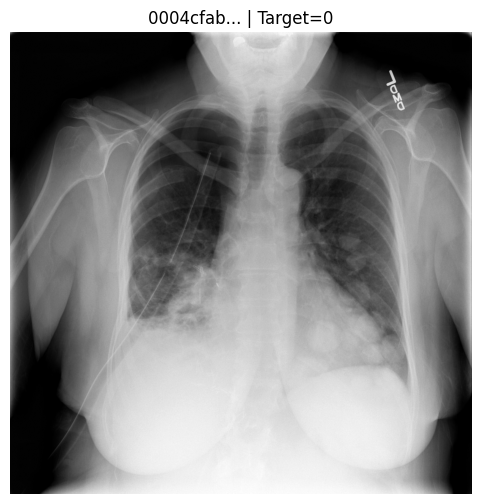

In [34]:
# %% [CELDA 10] -- Función para dibujar una imagen con sus bounding boxes
def load_dicom_image(patient_id, img_dir=TRAIN_IMG_DIR):
    path = os.path.join(img_dir, f"{patient_id}.dcm")
    dcm = pydicom.dcmread(path)
    return dcm.pixel_array
 
def plot_patient(patient_id, ax=None):
    img = load_dicom_image(patient_id)
    boxes = train_labels[train_labels["patientId"] == patient_id]
 
    if ax is None:
        fig, ax = plt.subplots(1, figsize=(6, 6))
 
    ax.imshow(img, cmap="gray")
    target = boxes["Target"].iloc[0]
    ax.set_title(f"{patient_id[:8]}... | Target={target}")
    ax.axis("off")
 
    if target == 1:
        for _, row in boxes.iterrows():
            rect = patches.Rectangle(
                (row["x"], row["y"]), row["width"], row["height"],
                linewidth=2, edgecolor="red", facecolor="none"
            )
            ax.add_patch(rect)
    return ax
 
# Ejemplo individual
plot_patient(sample_id)
plt.show()

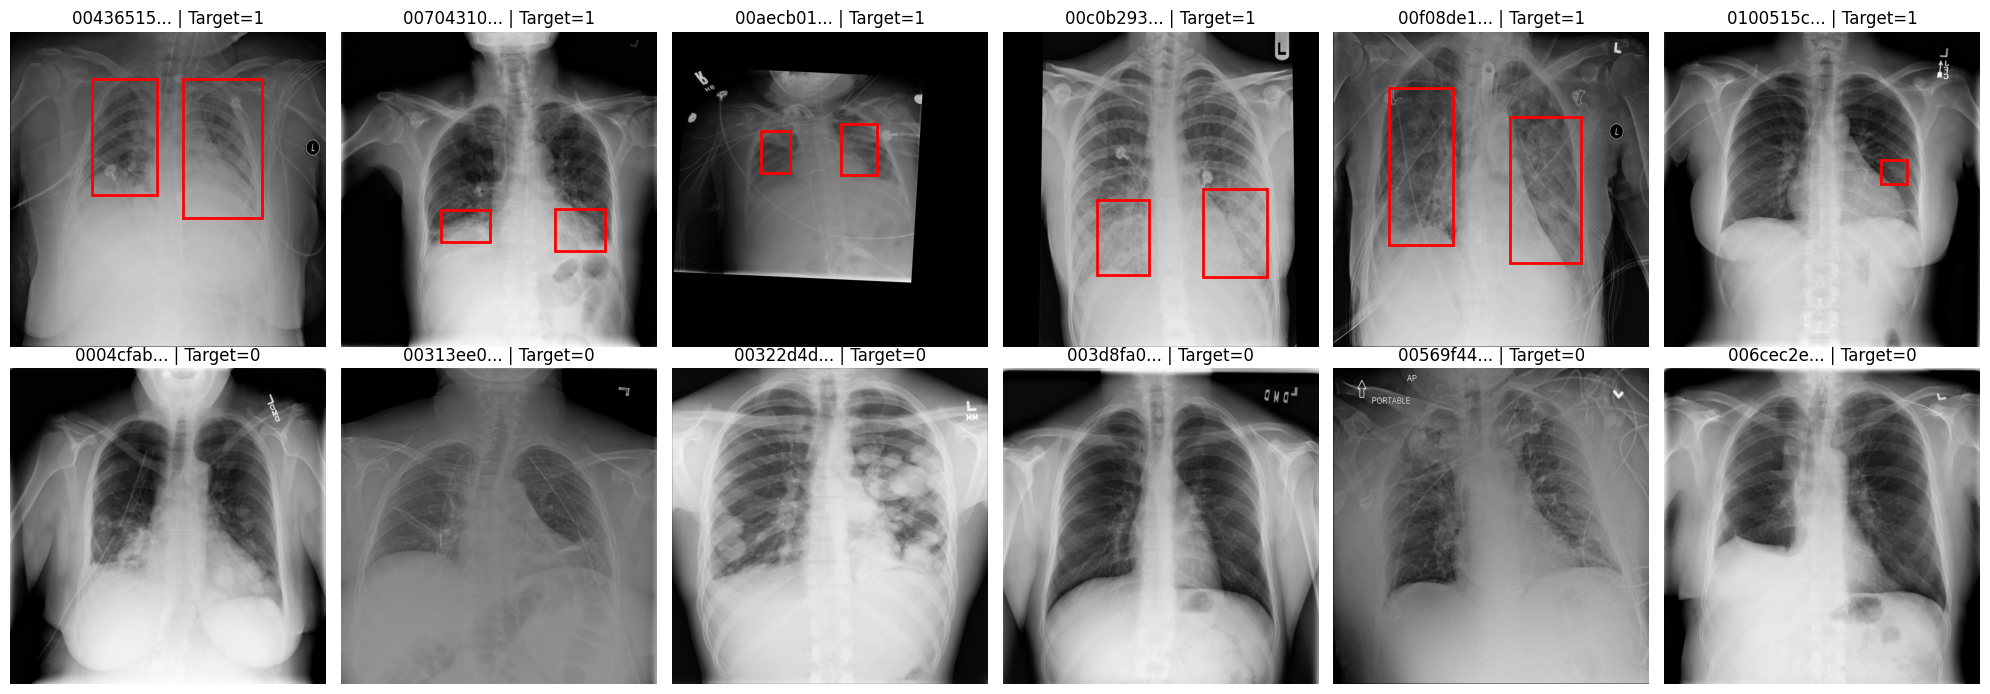

In [35]:
# %% [CELDA 11] -- Grid de ejemplos: positivos y negativos
positive_ids = train_labels[train_labels["Target"] == 1]["patientId"].unique()[:6]
negative_ids = train_labels[train_labels["Target"] == 0]["patientId"].unique()[:6]
 
fig, axes = plt.subplots(2, 6, figsize=(20, 7))
 
for i, pid in enumerate(positive_ids):
    plot_patient(pid, ax=axes[0, i])
for i, pid in enumerate(negative_ids):
    plot_patient(pid, ax=axes[1, i])
 
axes[0, 0].set_ylabel("POSITIVOS", fontsize=14)
axes[1, 0].set_ylabel("NEGATIVOS", fontsize=14)
plt.tight_layout()
plt.show()

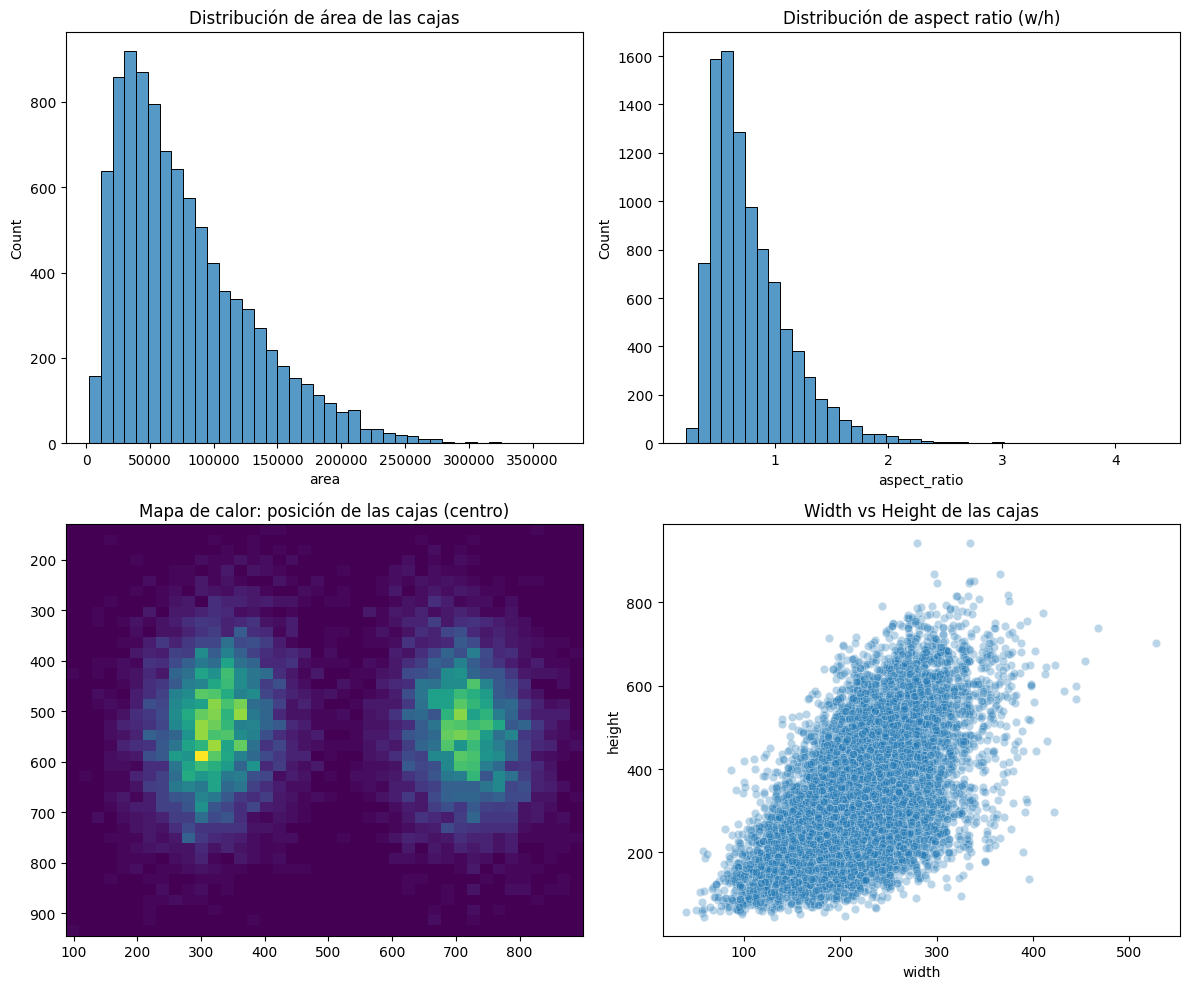

             width       height           area
count  9555.000000  9555.000000    9555.000000
mean    218.471376   329.269702   77523.448038
std      59.289475   157.750755   51807.689206
min      40.000000    45.000000    2320.000000
25%     177.000000   203.000000   37535.500000
50%     217.000000   298.000000   64829.000000
75%     259.000000   438.000000  106491.500000
max     528.000000   942.000000  371184.000000


In [36]:
# %% [CELDA 12] -- Análisis de tamaño y posición de las bounding boxes
positive_boxes = train_labels[train_labels["Target"] == 1].copy()
positive_boxes["area"] = positive_boxes["width"] * positive_boxes["height"]
positive_boxes["aspect_ratio"] = positive_boxes["width"] / positive_boxes["height"]
positive_boxes["x_center"] = positive_boxes["x"] + positive_boxes["width"] / 2
positive_boxes["y_center"] = positive_boxes["y"] + positive_boxes["height"] / 2
 
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
 
sns.histplot(positive_boxes["area"], ax=axes[0, 0], bins=40)
axes[0, 0].set_title("Distribución de área de las cajas")
 
sns.histplot(positive_boxes["aspect_ratio"], ax=axes[0, 1], bins=40)
axes[0, 1].set_title("Distribución de aspect ratio (w/h)")
 
axes[1, 0].hist2d(positive_boxes["x_center"], positive_boxes["y_center"], bins=40)
axes[1, 0].set_title("Mapa de calor: posición de las cajas (centro)")
axes[1, 0].invert_yaxis()  # eje y de imagen va hacia abajo
 
sns.scatterplot(data=positive_boxes, x="width", y="height", alpha=0.3, ax=axes[1, 1])
axes[1, 1].set_title("Width vs Height de las cajas")
 
plt.tight_layout()
plt.show()
 
print(positive_boxes[["width", "height", "area"]].describe())
 
# Qué observar:
# - El mapa de calor de posiciones debería mostrar 2 "lóbulos" (uno por pulmón),
#   ya que la neumonía suele aparecer en zonas pulmonares específicas.
# - Esto es útil para luego decidir tamaños de anchor boxes en el modelo.

In [37]:
# %% [CELDA 13] -- Tamaño real de las imágenes (¿todas son 1024x1024?)
print(meta_df[["Rows", "Columns"]].drop_duplicates())
# Si todas son 1024x1024 (lo normal en este dataset), no hay que preocuparse
# por resize heterogéneo; sí habrá que decidir a qué tamaño reescalar para
# entrenar (512, 256, etc.) por motivos de memoria/velocidad.

   Rows  Columns
0  1024     1024


#  [CELDA 14] -- Resumen de hallazgos (rellenar después de correr todo)
"""
RESUMEN EDA - completar con tus observaciones reales:
 
1. Balance de clases:
   - Target=0: ~77.5%  | Target=1: ~22.5%
   - Dentro de Target=0: Normal ~29.28% / No Lung Opacity-Not Normal ~39.11%
 
2. Bounding boxes:
   - La mayoría de positivos tiene 1 o 2 cajas (ver CELDA 4)
   - Tamaño típico de caja: ancho ~218.471376 px, alto ~329.269702 px (sobre imagen 1024x1024)
   - Las cajas se concentran en las zonas pulmonares medias/inferiores
 
3. Metadatos:
   - Vista (AP/PA): ¿correlaciona con Target?

AP: mayor numero de pacientes con neumonia
   - Edad/Sexo: ¿algún sesgo notable?

Tasa de Target=1 por rango de edad (y tamaño de muestra):
           tasa_positivos_%  n_pacientes
AgeBin                                  
(0, 10]               31.95          435
(10, 20]              26.02         1468
(20, 30]              25.24         3205
(30, 40]              24.80         3936
(40, 50]              20.84         5048
(50, 60]              21.14         6619
(60, 70]              20.14         4279
(70, 80]              22.93         1452
(80, 100]             25.32          237

 
4. Implicaciones para el baseline:
   - Dataset desbalanceado -> usar Focal Loss o pesos de clase
   - Todas las imágenes 1024x1024 -> decidir tamaño de resize (p.ej. 256 o 512)
   - Necesitamos convertir el problema en 2 sub-tareas posibles:
     a) Clasificación binaria simple (¿hay neumonía?) -> baseline rápido
     b) Detección real con bounding boxes -> modelo final (RetinaNet)


In [1]:
%%bash
# 1. Asegúrate de estar dentro de la carpeta del repositorio
cd /kaggle/working/RSNAPneumonia

# 2. Añade los cambios que hiciste (incluyendo el notebook modificado)
git add .

# 3. Guarda el estado actual con un mensaje descriptivo
git commit -m "Añado análisis exploratorio de metadatos (Edad, Sexo, Vista AP/PA)"

# 4. Sube los cambios ÚNICAMENTE a tu rama (Reemplaza 'tu-nombre-de-rama' por el tuyo)
git push origin lorena

bash: line 2: cd: /kaggle/working/RSNAPneumonia: No such file or directory
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).
fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


CalledProcessError: Command 'b'# 1. Aseg\xc3\xbarate de estar dentro de la carpeta del repositorio\ncd /kaggle/working/RSNAPneumonia\n\n# 2. A\xc3\xb1ade los cambios que hiciste (incluyendo el notebook modificado)\ngit add .\n\n# 3. Guarda el estado actual con un mensaje descriptivo\ngit commit -m "A\xc3\xb1ado an\xc3\xa1lisis exploratorio de metadatos (Edad, Sexo, Vista AP/PA)"\n\n# 4. Sube los cambios \xc3\x9aNICAMENTE a tu rama (Reemplaza \'tu-nombre-de-rama\' por el tuyo)\ngit push origin lorena\n'' returned non-zero exit status 128.

# Verificar estructura
compruebo qué archivos y carpetas trae el dataset antes de explorar

In [4]:
for elemento in sorted(os.listdir(RUTA_DATOS)):
    ruta = os.path.join(RUTA_DATOS, elemento)
    if os.path.isdir(ruta):
        n = len(os.listdir(ruta))
        print(f'[dir]  {elemento}/ — {n} archivos')
    else:
        print(f'[file] {elemento}')

[file] GCP Credits Request Link - RSNA.txt
[file] stage_2_detailed_class_info.csv
[file] stage_2_sample_submission.csv
[dir]  stage_2_test_images/ — 3000 archivos
[dir]  stage_2_train_images/ — 26684 archivos
[file] stage_2_train_labels.csv


#  Leer CSV de labels

In [5]:
df_labels = pd.read_csv(f'{RUTA_DATOS}/stage_2_train_labels.csv')
print(df_labels.shape)
df_labels.head(10)

(30227, 6)


,patientId,x,y,width,height,Target
0,0004cfab-14fd-4e49-80ba-63a80b6bddd6,NaN,NaN,NaN,NaN,0
1,00313ee0-9eaa-42f4-b0ab-c148ed3241cd,NaN,NaN,NaN,NaN,0
2,00322d4d-1c29-4943-afc9-b6754be640eb,NaN,NaN,NaN,NaN,0
3,003d8fa0-6bf1-40ed-b54c-ac657f8495c5,NaN,NaN,NaN,NaN,0
4,00436515-870c-4b36-a041-de91049b9ab4,264.0,152.0,213.0,379.0,1
5,00436515-870c-4b36-a041-de91049b9ab4,562.0,152.0,256.0,453.0,1
6,00569f44-917d-4c86-a842-81832af98c30,NaN,NaN,NaN,NaN,0
7,006cec2e-6ce2-4549-bffa-eadfcd1e9970,NaN,NaN,NaN,NaN,0
8,00704310-78a8-4b38-8475-49f4573b2dbb,323.0,577.0,160.0,104.0,1
9,00704310-78a8-4b38-8475-49f4573b2dbb,695.0,575.0,162.0,137.0,1


# EXPLORACIÓN DEL DATASET

# Distribución de clases

In [6]:
# verifico el balance entre positivos y negativos porque afecta directamente a la estrategia de entrenamiento
conteo = df_labels.groupby('Target')['patientId'].nunique()
print(conteo)
print(f'\nratio positivos: {conteo[1] / conteo.sum():.2%}')

Target
0    20672
1     6012
Name: patientId, dtype: int64

ratio positivos: 22.53%


# Clases detalladas

No Lung Opacity / Not Normal: Sin opacidad pulmonar / No normal (significa que la radiografía muestra alguna anomalía, pero no es la opacidad típica de una neumonía; podría ser otra condición médica).

Lung Opacity: Opacidad pulmonar (este es el grupo positivo para neumonía, donde se ven las manchas blanquecinas en los pulmones).

Normal: Normal (pulmones completamente sanos y sin hallazgos extraños).

In [7]:
# cargo el csv con las 3 clases para entender cuántos casos son anómalos pero sin neumonía
df_clases = pd.read_csv(f'{RUTA_DATOS}/stage_2_detailed_class_info.csv')
print(df_clases['class'].value_counts())

class
No Lung Opacity / Not Normal    11821
Lung Opacity                     9555
Normal                           8851
Name: count, dtype: int64


# Ejemplo DICOM

In [8]:
# leo un dicom de ejemplo para entender su estructura antes de planificar la conversión a PNG
ruta_train = f'{RUTA_DATOS}/stage_2_train_images'
ejemplo_id  = df_labels['patientId'].iloc[0]
dcm         = pydicom.dcmread(f'{ruta_train}/{ejemplo_id}.dcm')

print(f'shape:             {dcm.pixel_array.shape}')
print(f'dtype:             {dcm.pixel_array.dtype}')
print(f'min/max:           {dcm.pixel_array.min()} / {dcm.pixel_array.max()}')
print(f'PhotometricInterp: {dcm.PhotometricInterpretation}')

shape:             (1024, 1024)
dtype:             uint8
min/max:           0 / 245
PhotometricInterp: MONOCHROME2


Esto describe las propiedades técnicas de una de las imágenes radiográficas (en formato DICOM)

MONOCHROME2 $\rightarrow$ Interpretación fotométrica: Esto es clave en medicina. Significa que el 0 es negro y el valor más alto es blanco.Nota: Si dijera MONOCHROME1, la imagen estaría invertida (el 0 sería blanco y el 255 negro, como un negativo fotográfico). 

Al ser MONOCHROME2, puedes visualizarla directamente de forma normal: los huesos y zonas densas se verán blancos/claros, y el aire (los pulmones sanos) se verá negro/oscuro.

# Visualizar ejemplos con bounding box

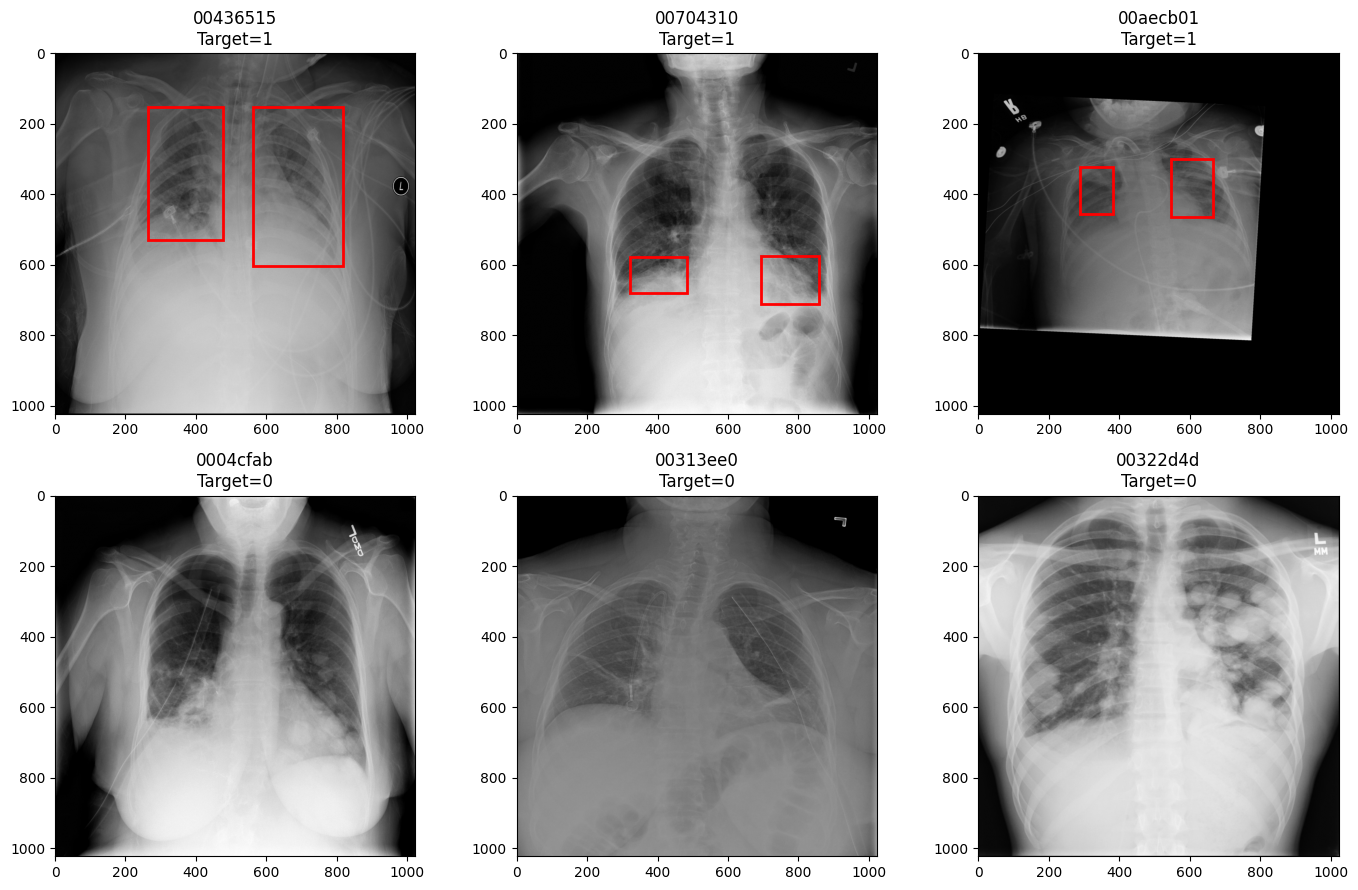

In [9]:
# muestro casos positivos y negativos para entender visualmente cómo se ve la neumonía en la radiografía
def mostrar_caso(patient_id, ax):
    dcm   = pydicom.dcmread(f'{ruta_train}/{patient_id}.dcm')
    img   = dcm.pixel_array
    filas = df_labels[df_labels['patientId'] == patient_id]
    ax.imshow(img, cmap='gray')
    ax.set_title(f'{patient_id[:8]}\nTarget={filas["Target"].iloc[0]}')
    for _, fila in filas.iterrows():
        if fila['Target'] == 1:
            rect = patches.Rectangle(
                (fila['x'], fila['y']), fila['width'], fila['height'],
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)

positivos = df_labels[df_labels['Target'] == 1]['patientId'].unique()[:3]
negativos = df_labels[df_labels['Target'] == 0]['patientId'].unique()[:3]

fig, axes = plt.subplots(2, 3, figsize=(14, 9))
for ax, pid in zip(axes[0], positivos):
    mostrar_caso(pid, ax)
for ax, pid in zip(axes[1], negativos):
    mostrar_caso(pid, ax)
plt.tight_layout()
plt.show()

Estás viendo un análisis exploratorio de datos (EDA) donde comparan ejemplos positivos de neumonía frente a negativos. Vamos a desglosarlo en dos partes:

1. La fila de arriba: Target = 1 (Casos Positivos)
Estas tres radiografías pertenecen a pacientes que sí tienen neumonía (opacidad pulmonar).

Las cajas rojas (Bounding Boxes): Son las etiquetas (ground truth) que los radiólogos expertos dibujaron a mano. Le indican a tu modelo la ubicación exacta de la infección.

Fíjate que la neumonía suele aparecer en ambos pulmones o en zonas específicas, viéndose como manchas blancas difusas (opacidades) donde normalmente debería verse oscuro (aire).

El objetivo de tu IA: Cuando le pases una imagen nueva, tu modelo tendrá que ser capaz de adivinar y dibujar esas mismas cajas rojas en el lugar correcto.

2. La fila de abajo: Target = 0 (Casos Negativos)
Estas tres radiografías pertenecen a pacientes que no tienen opacidad por neumonía.

Sin cajas rojas: Como el objetivo es detectar opacidad pulmonar por neumonía, aquí no hay ninguna caja que dibujar.

El truco médico (¡Ojo con la tercera imagen!): Mira la imagen de abajo a la derecha (00322d4d). Tiene unas manchas blancas gigantescas y muy marcadas en el pulmón derecho (a tu izquierda). Cualquiera pensaría que está enfermo, ¡y lo está! Pero el médico determinó que no es la opacidad típica de una neumonía (podría ser un tumor, líquido u otra patología).

Esto demuestra por qué el reto es difícil: tu modelo tiene que aprender a diferenciar la opacidad de la neumonía de otras manchas o problemas pulmonares.

¿Qué te dice esto para tu código?
Que estás ante un problema clásico de Detección de Objetos. Tu modelo no solo tendrá que decir "sí o no" (Target 1 o 0), sino que si dice "sí", tendrá que dar las coordenadas de esas cajitas rojas.


# Análisis de bounding boxes

total bounding boxes: 9555
pacientes con 1 box:  2614
pacientes con 2+ box: 3398

            x       y   width  height
count  9555.0  9555.0  9555.0  9555.0
mean    394.0   366.8   218.5   329.3
std     204.6   148.9    59.3   157.8
min       2.0     2.0    40.0    45.0
25%     207.0   249.0   177.0   203.0
50%     324.0   365.0   217.0   298.0
75%     594.0   478.5   259.0   438.0
max     835.0   881.0   528.0   942.0


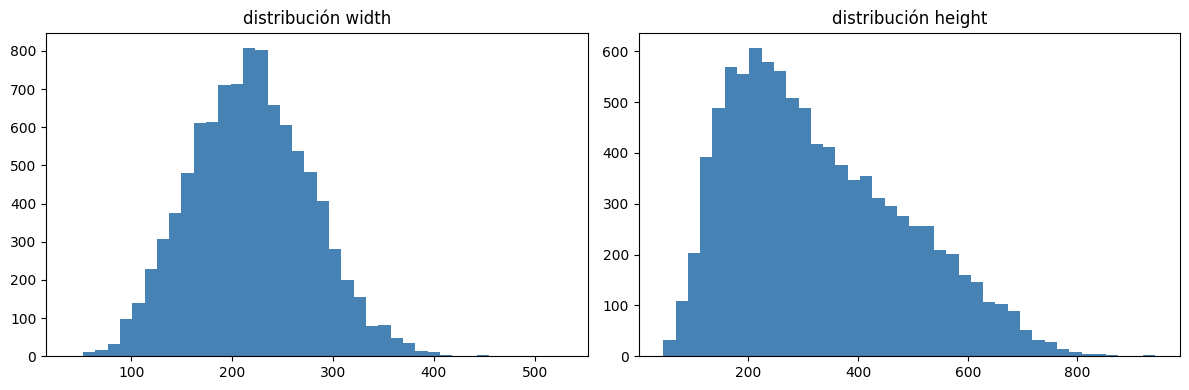

In [10]:
# analizo tamaños y distribución de las boxes para entender qué escala tienen los focos de neumonía
df_pos = df_labels[df_labels['Target'] == 1].copy()

print(f'total bounding boxes: {len(df_pos)}')
print(f'pacientes con 1 box:  {(df_pos.groupby("patientId").size() == 1).sum()}')
print(f'pacientes con 2+ box: {(df_pos.groupby("patientId").size() > 1).sum()}')
print()
print(df_pos[['x', 'y', 'width', 'height']].describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(df_pos['width'],  bins=40, color='steelblue')
axes[0].set_title('distribución width')
axes[1].hist(df_pos['height'], bins=40, color='steelblue')
axes[1].set_title('distribución height')
plt.tight_layout()
plt.show()

In [10]:
!git branch

fatal: not a git repository (or any parent up to mount point /kaggle)
Stopping at filesystem boundary (GIT_DISCOVERY_ACROSS_FILESYSTEM not set).


In [11]:
!git config --global user.name "AlorenaP"
!git config --global user.email "alperez9221@gmail.com"

In [12]:
!git clone https://github.com/franciscofdzfer/RSNAPneumonia

Cloning into 'RSNAPneumonia'...
remote: Enumerating objects: 12, done.
remote: Counting objects: 100% (12/12), done.
remote: Compressing objects: 100% (10/10), done.
remote: Total 12 (delta 3), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (12/12), 526.77 KiB | 10.75 MiB/s, done.
Resolving deltas: 100% (3/3), done.


In [14]:
%%bash
cd RSNAPneumonia
git fetch origin
git checkout lorena
git pull origin lorena

Branch 'lorena' set up to track remote branch 'lorena' from 'origin'.
Already up to date.


Switched to a new branch 'lorena'
From https://github.com/franciscofdzfer/RSNAPneumonia
 * branch            lorena     -> FETCH_HEAD
